In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")

In [5]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    504 non-null    object 
 1   FB      504 non-null    float64
 2   GOOG    504 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.9+ KB


In [8]:
# changing date type to datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    504 non-null    datetime64[ns]
 1   FB      504 non-null    float64       
 2   GOOG    504 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 11.9 KB


In [10]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


## Task 1

In [17]:
# TODO verify

fb_daily_returns = df["FB"].shift(-1) - df["FB"]
goog_daily_returns = df["GOOG"].shift(-1) - df["GOOG"]

fb_daily_mean = fb_daily_returns.mean()
fb_daily_std = fb_daily_returns.std()
print(f"FB daily return mean: {fb_daily_mean} and standard deviation: {fb_daily_std}")

goog_daily_mean = goog_daily_returns.mean()
goog_daily_std = goog_daily_returns.std()
print(f"GOOG daily return mean: {goog_daily_mean} and standard deviation: {goog_daily_std}")

FB daily return mean: 0.07276341948310137 and standard deviation: 1.7073905784396446
GOOG daily return mean: 0.49107355864811153 and standard deviation: 10.26848443298013


## Task 2

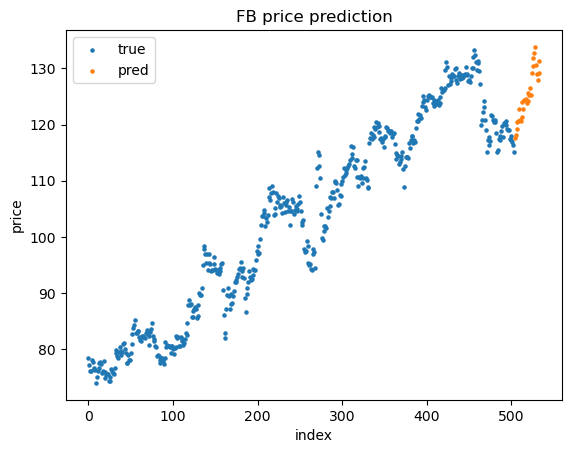

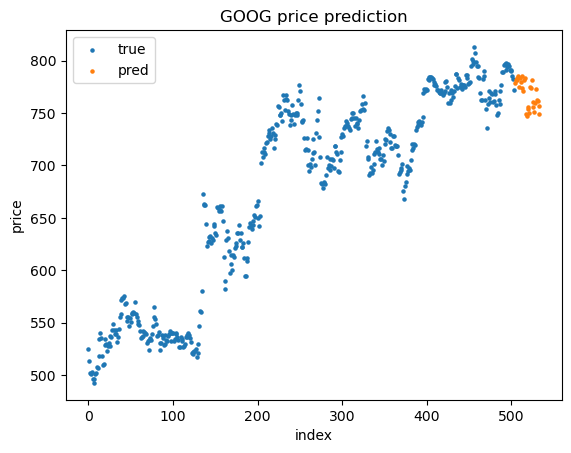

In [49]:
# TODO price simulation (normal assumption?)

days = 30

fb_returns_pred = np.random.normal(loc=fb_daily_mean, scale=fb_daily_std, size=days)
fb_returns_cum = np.cumsum(fb_returns_pred)
fb_last_price = df["FB"].iloc[-1]
fb_price_pred = fb_last_price + fb_returns_cum

idx_start = df.index[-1] + 1
idx_end = idx_start + days
pred_index = np.arange(idx_start, idx_end)

plt.scatter(df.index, df["FB"], s=5)
plt.scatter(pred_index, fb_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("FB price prediction")
plt.show()


goog_returns_pred = np.random.normal(loc=goog_daily_mean, scale=goog_daily_std, size=days)
goog_returns_cum = np.cumsum(goog_returns_pred)
goog_last_price = df["GOOG"].iloc[-1]
goog_price_pred = goog_last_price + goog_returns_cum

plt.scatter(df.index, df["GOOG"], s=5)
plt.scatter(pred_index, goog_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("GOOG price prediction")
plt.show()

## Task 3

In [50]:
def predict_price(mean, std, days, last_price):
    returns_pred = np.random.normal(loc=mean, scale=std, size=days)
    returns_cum = np.cumsum(returns_pred)
    price_pred = last_price + returns_cum
    return price_pred

days = 60
n = 1000
goog_last_price = df["GOOG"].iloc[-1]
exp_sum = 0

for i in range(n):
    preds = predict_price(goog_daily_mean, goog_daily_std, days, goog_last_price)
    pred = preds[-1]
    exp_sum += pred

avg_price = exp_sum / n

print(f"Average ending price is {avg_price}")

Average ending price is 799.4713273058269
